<a href="https://colab.research.google.com/github/httperror505/Neural-Network/blob/colab/Whole_Customers_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load the dataset from Google Drive
file_path = '/content/drive/MyDrive/Datasets/Wholesale customers data.csv'
df = pd.read_csv(file_path)

# Display basic information about the dataset
print("Dataset Information:")
print(df.info())

# Display the first few rows of the dataset
print("\nFirst few rows of the dataset:")
print(df.head())

# Perform data organization if needed
# (You may need to handle missing values, categorical data, etc.)

# Select relevant columns for clustering
selected_columns = df.iloc[:, 1:].values  # Adjust the columns as per your dataset

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(selected_columns)

# Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_data)

# Display the resulting clusters
print("\nClusters:")
print(df['cluster'].value_counts())

# Evaluate the clusters, you may need to adjust this based on your dataset
# For example, calculate cluster means, centroids, or any other relevant metrics

# Save the K-means model
model_path = '/content/drive/My Drive/Colab Notebooks/kmeans_model.pth'
joblib.dump(kmeans, model_path)
print("\nK-means model saved to:", model_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None

First few rows of the dataset:
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


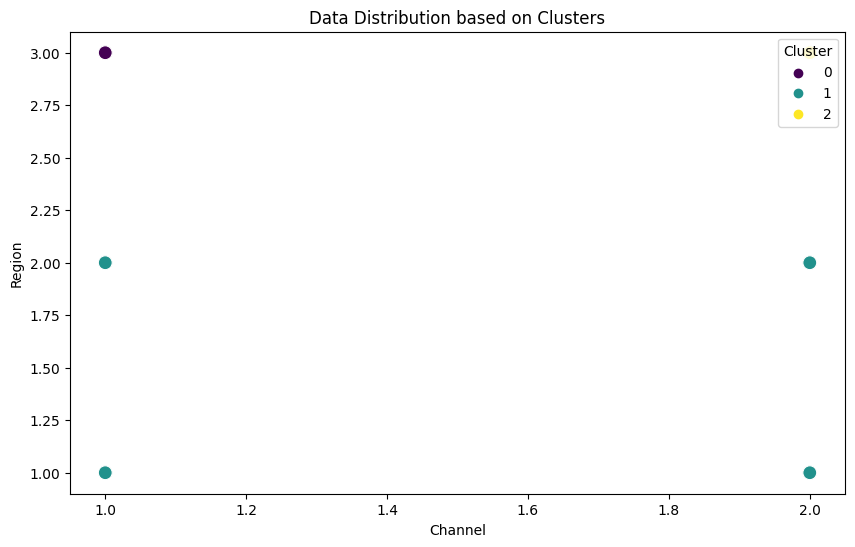

In [ ]:
# Visualize the distribution of data points based on clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df.columns[0], y=df.columns[1], hue='cluster', data=df, palette='viridis', s=100)
plt.title('Data Distribution based on Clusters')
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.legend(title='Cluster', loc='upper right')
plt.show()


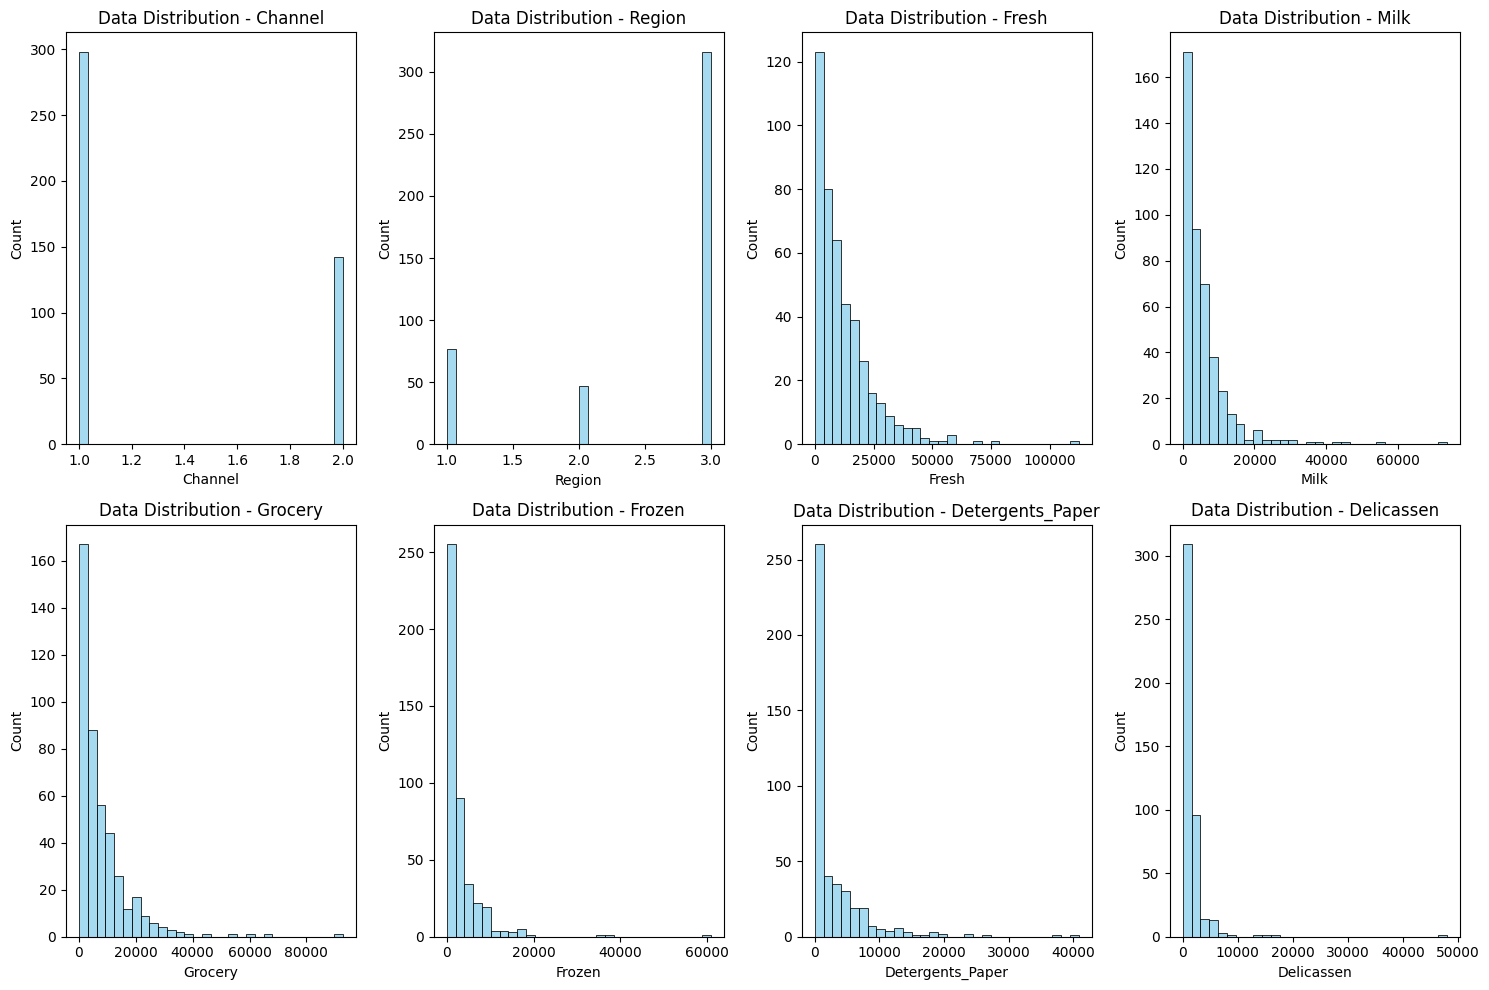

In [ ]:
# Visualize the sorted data distribution for each column
plt.figure(figsize=(15, 10))

for i, column in enumerate(df.columns[:-1]):  # Exclude the 'cluster' column
    plt.subplot(2, 4, i+1)
    sns.histplot(df[column], kde=False, bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Data Distribution - {column}')
    plt.xlabel(column)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


In [ ]:
# Save the K-means model
model_path = '/content/drive/My Drive/Colab Notebooks/kmeans_model.pth'
joblib.dump(kmeans, model_path)
print("\nK-means model saved to:", model_path)


K-means model saved to: /content/drive/My Drive/Colab Notebooks/kmeans_model.pth


**Whole Customers Dataset**

Analysis Method Used: **K-Means Clustering**

**AI Prompt:**
https://chat.openai.com/share/00792c86-6106-4177-993a-0f2acc718aaf